# Movie Genre Multi-Label Classification
## HW6: Three Approaches - Naive Bayes, BERT, and Decoder Model

**Dataset:** Kaggle Movie Genre Prediction Competition

## Setup and Data Loading

In [ ]:
# Install required packages
!pip install transformers datasets evaluate accelerate scikit-learn pandas numpy torch
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Hofstra/year3/text mining/final lab
%ls *.csv

import pandas as pd
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
genres_df = pd.read_csv('movies_genres.csv')

In [6]:
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.multiclass import OneVsRestClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import MultiLabelBinarizer
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [7]:
# Load the Kaggle dataset
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
genres_df = pd.read_csv('movies_genres.csv')

print(f"Train set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")
print(f"\nGenres available: {len(genres_df)}")
print(genres_df.head())

Train set: 8000 samples
Test set: 2000 samples

Genres available: 19
   id       name
0  28     Action
1  12  Adventure
2  16  Animation
3  35     Comedy
4  80      Crime


In [8]:
import ast

# Convert genre IDs from string representation of lists to actual lists
train_df['genre_list'] = train_df['genre_ids'].apply(lambda x: ast.literal_eval(x))

# Create genre mappings - using correct column names
id2genre = dict(zip(genres_df['id'], genres_df['name']))
genre2id = {v: k for k, v in id2genre.items()}
all_genres = sorted(id2genre.values())
num_genres = len(all_genres)

print(f"Total unique genres: {num_genres}")
print(f"Genres: {all_genres}")

Total unique genres: 19
Genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [9]:
# Split training data: 90% train, 10% validation
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(train_df, test_size=0.1, random_state=42)

print(f"Training set: {len(train_data)} samples")
print(f"Validation set: {len(val_data)} samples")

Training set: 7200 samples
Validation set: 800 samples


---
## Part 1: Naive Bayes Classifier (From Scratch)

### Text Preprocessing

In [10]:
def preprocess_text(text):
    """Basic text preprocessing: lowercase, remove special chars, tokenize"""
    text = str(text).lower()
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Split into tokens
    tokens = text.split()
    # Remove very short tokens (< 3 chars)
    tokens = [t for t in tokens if len(t) >= 3]
    return tokens

# Test preprocessing - using correct column name
sample_text = train_data.iloc[0]['overview']  # Changed to 'overview'
print(f"Original: {sample_text[:100]}...")
print(f"Tokens: {preprocess_text(sample_text)[:20]}")

Original: After the Creed family's cat is accidentally killed, a friendly neighbor advises its burial in a mys...
Tokens: ['after', 'the', 'creed', 'familys', 'cat', 'accidentally', 'killed', 'friendly', 'neighbor', 'advises', 'its', 'burial', 'mysterious', 'nearby', 'cemetery']


In [11]:
# Build vocabulary from training data
def build_vocabulary(texts, min_freq=5, max_vocab_size=5000):
    """Build vocabulary with frequency filtering"""
    word_counts = Counter()

    for text in texts:
        tokens = preprocess_text(text)
        word_counts.update(tokens)

    # Filter by minimum frequency and take top words
    vocab = [word for word, count in word_counts.most_common(max_vocab_size)
             if count >= min_freq]

    return vocab

# Build vocabulary from training set
vocabulary = build_vocabulary(train_data['overview'])
vocab_set = set(vocabulary)

print(f"Vocabulary size: {len(vocabulary)}")
print(f"Top 20 words: {vocabulary[:20]}")

Vocabulary size: 5000
Top 20 words: ['the', 'and', 'his', 'with', 'her', 'for', 'their', 'when', 'that', 'from', 'who', 'but', 'they', 'she', 'after', 'into', 'has', 'are', 'life', 'him']


### Custom Naive Bayes Estimator

In [12]:
class CustomNaiveBayes(BaseEstimator, ClassifierMixin):
    """Custom Multinomial Naive Bayes for text classification"""

    def __init__(self, vocabulary, alpha=1.0):
        self.vocabulary = vocabulary
        self.vocab_set = set(vocabulary)
        self.alpha = alpha  # Laplace smoothing
        self.class_log_prior = None
        self.feature_log_prob = None

    def fit(self, X, y):
        """Train the Naive Bayes classifier"""
        n_samples = len(X)
        n_vocab = len(self.vocabulary)

        # Count class occurrences for prior probabilities
        class_counts = Counter(y)
        n_classes = len(class_counts)

        # Calculate log prior: P(class)
        self.class_log_prior = {}
        for cls in class_counts:
            self.class_log_prior[cls] = np.log(class_counts[cls] / n_samples)

        # Calculate feature probabilities: P(word|class)
        self.feature_log_prob = {}

        for cls in class_counts:
            # Count word occurrences in this class
            word_counts = Counter()
            total_words = 0

            for i, label in enumerate(y):
                if label == cls:
                    tokens = preprocess_text(X[i])
                    # Only count words in vocabulary
                    tokens = [t for t in tokens if t in self.vocab_set]
                    word_counts.update(tokens)
                    total_words += len(tokens)

            # Calculate log probabilities with Laplace smoothing
            feature_probs = {}
            for word in self.vocabulary:
                count = word_counts[word]
                # Laplace smoothing: (count + alpha) / (total + alpha * vocab_size)
                prob = (count + self.alpha) / (total_words + self.alpha * n_vocab)
                feature_probs[word] = np.log(prob)

            self.feature_log_prob[cls] = feature_probs

        # Store classes for predict_proba
        self.classes_ = sorted(class_counts.keys())

        return self

    def predict_proba(self, X):
        """Predict probability for each class - REQUIRED for OneVsRestClassifier"""
        probas = []

        for text in X:
            tokens = preprocess_text(text)
            # Only use words in vocabulary
            tokens = [t for t in tokens if t in self.vocab_set]

            # Calculate log probability for each class
            class_scores = {}
            for cls in self.class_log_prior:
                # Start with prior
                score = self.class_log_prior[cls]
                # Add feature probabilities
                for word in tokens:
                    if word in self.feature_log_prob[cls]:
                        score += self.feature_log_prob[cls][word]
                class_scores[cls] = score

            # Convert log scores to probabilities using softmax
            max_score = max(class_scores.values())
            exp_scores = {cls: np.exp(score - max_score) for cls, score in class_scores.items()}
            total = sum(exp_scores.values())

            # Return probabilities in order of self.classes_ (sklearn requirement)
            proba_row = [exp_scores[cls] / total for cls in self.classes_]
            probas.append(proba_row)

        return np.array(probas)

    def predict(self, X):
        """Predict class for each sample"""
        probas = self.predict_proba(X)
        return self.classes_[np.argmax(probas, axis=1)]

    def score(self, X, y):
        """Calculate accuracy"""
        predictions = self.predict(X)
        return accuracy_score(y, predictions)

### Train Naive Bayes with OneVsRestClassifier

In [13]:
# Prepare binary labels for multi-label classification
# Force MultiLabelBinarizer to use ALL 19 genres from genres_df
all_genre_ids = genres_df['id'].tolist()  # Get all 19 genre IDs

mlb = MultiLabelBinarizer(classes=all_genre_ids)  # Force all 19 genres
y_train_binary = mlb.fit_transform(train_data['genre_list'])
y_val_binary = mlb.transform(val_data['genre_list'])

print(f"Binary label shape: {y_train_binary.shape}")
print(f"Example binary label: {y_train_binary[0]}")
print(f"Number of genres: {len(mlb.classes_)}")
print(f"All genre IDs: {mlb.classes_}")

Binary label shape: (7200, 19)
Example binary label: [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
Number of genres: 19
All genre IDs: [   28    12    16    35    80    99    18 10751    14    36    27 10402
  9648 10749   878 10770    53 10752    37]


In [14]:
# Train OneVsRest classifier with our custom Naive Bayes
nb_classifier = CustomNaiveBayes(vocabulary=vocabulary, alpha=1.0)
ovr_nb = OneVsRestClassifier(nb_classifier)

print("Training Naive Bayes with OneVsRest...")
ovr_nb.fit(train_data['overview'].values, y_train_binary)
print("Training complete!")

Training Naive Bayes with OneVsRest...
Training complete!


### Evaluate Naive Bayes

In [15]:
def evaluate_multilabel(y_true, y_pred, dataset_name="Test"):
    """Calculate metrics for multi-label classification"""
    print(f"\n{'='*50}")
    print(f"{dataset_name} Set Results")
    print(f"{'='*50}")

    # Overall metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_micro = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)

    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nMicro-averaged scores:")
    print(f"  Precision: {precision_micro:.4f}")
    print(f"  Recall: {recall_micro:.4f}")
    print(f"  F1: {f1_micro:.4f}")
    print(f"\nMacro-averaged scores:")
    print(f"  Precision: {precision_macro:.4f}")
    print(f"  Recall: {recall_macro:.4f}")
    print(f"  F1: {f1_macro:.4f}")

    return {
        'accuracy': accuracy,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro
    }

# Evaluate on training set
y_train_pred = ovr_nb.predict(train_data['overview'].values)
nb_train_metrics = evaluate_multilabel(y_train_binary, y_train_pred, "Training")

# Evaluate on validation set
y_val_pred = ovr_nb.predict(val_data['overview'].values)
nb_val_metrics = evaluate_multilabel(y_val_binary, y_val_pred, "Validation")


Training Set Results
Accuracy: 0.2710

Micro-averaged scores:
  Precision: 0.7084
  Recall: 0.8115
  F1: 0.7564

Macro-averaged scores:
  Precision: 0.6563
  Recall: 0.7239
  F1: 0.6790

Validation Set Results
Accuracy: 0.1300

Micro-averaged scores:
  Precision: 0.5911
  Recall: 0.6172
  F1: 0.6039

Macro-averaged scores:
  Precision: 0.4681
  Recall: 0.4772
  F1: 0.4669


---
## Part 2: BERT Classifier

### Prepare Data for BERT

In [16]:
# Convert DataFrame to Hugging Face Dataset format
def create_dataset(df, label_column='genre_list'):
    """Convert DataFrame to Dataset with binary labels"""
    data_dict = {
        'text': df['overview'].tolist(),  # Changed from 'plot' to 'overview'
        'labels': mlb.transform(df[label_column]).astype(np.float32).tolist()  # Convert to float32
    }
    return Dataset.from_dict(data_dict)

train_dataset = create_dataset(train_data)
val_dataset = create_dataset(val_data)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Validation dataset: {len(val_dataset)} samples")
print(f"Example: {train_dataset[0]}")

Train dataset: 7200 samples
Validation dataset: 800 samples
Example: {'text': "After the Creed family's cat is accidentally killed, a friendly neighbor advises its burial in a mysterious nearby cemetery.", 'labels': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}


In [ ]:
# Initialize BERT tokenizer
MODEL_NAME = "distilbert-base-uncased"  # Faster than full BERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    """Tokenize text for BERT"""
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

# Tokenize datasets
train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)

print("Tokenization complete")

### Configure BERT Model

In [ ]:
from transformers import AutoConfig

# Configure model for multi-label classification
config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=num_genres,
    problem_type="multi_label_classification"
)

# Load model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)
model.to(device)

print(f"Model loaded on {device}")
print(f"Number of labels: {num_genres}")

### Define Metrics and Training

In [19]:
def compute_metrics(eval_pred):
    """Compute metrics during training"""
    logits, labels = eval_pred
    # Apply sigmoid to get probabilities, threshold at 0.5
    predictions = (torch.sigmoid(torch.tensor(logits)) > 0.5).int().numpy()

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='micro', zero_division=0)
    recall = recall_score(labels, predictions, average='micro', zero_division=0)
    f1_micro = f1_score(labels, predictions, average='micro', zero_division=0)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro
    }

In [31]:
# Training arguments
training_args = TrainingArguments(
    output_dir="./bert_model",
    eval_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

print("Trainer initialized")

Trainer initialized


In [ ]:
# Train BERT model
trainer.train()

### Evaluate BERT

In [22]:
# Evaluate on validation set
bert_val_results = trainer.evaluate(val_tokenized)
print("\nBERT Validation Results:")
for key, value in bert_val_results.items():
    print(f"{key}: {value:.4f}")


BERT Validation Results:
eval_loss: 0.2243
eval_accuracy: 0.1600
eval_precision: 0.7515
eval_recall: 0.5234
eval_f1_micro: 0.6171
eval_f1_macro: 0.4259
eval_runtime: 1.5944
eval_samples_per_second: 501.7540
eval_steps_per_second: 31.3600
epoch: 3.0000


In [23]:
# Save BERT model
trainer.save_model("./best_bert_model")
tokenizer.save_pretrained("./best_bert_model")
print("Model saved")

Model saved


---
## Part 3: Decoder Model (GPT-2 Style)

### Zero-Shot Prompting

In [ ]:
from transformers import AutoModelForCausalLM, pipeline

# Load GPT-2 model for text generation
decoder_model = "gpt2"  # or "gpt2-medium" for better performance
generator = pipeline("text-generation", model=decoder_model, device=0 if torch.cuda.is_available() else -1)

print(f"Loaded decoder model: {decoder_model}")

In [25]:
def zero_shot_predict(plot, genres_list):
    """Zero-shot genre prediction using decoder model"""
    # Create prompt
    prompt = f"""Classify the following movie plot into one or more genres from this list: {', '.join(genres_list)}.

Plot: {plot[:500]}  # Truncate to avoid token limit

Genres:"""

    # Generate response
    response = generator(prompt, max_length=len(prompt.split()) + 30, num_return_sequences=1,
                        temperature=0.7, do_sample=True)

    generated_text = response[0]['generated_text']
    # Extract genres from response (simple heuristic)
    prediction_part = generated_text.split('Genres:')[-1].strip()

    # Match against known genres
    predicted_genres = []
    for genre in genres_list:
        if genre.lower() in prediction_part.lower():
            predicted_genres.append(genre2id[genre])

    return predicted_genres if predicted_genres else [genre2id[genres_list[0]]]  # Default to first genre

# Test on one example
test_plot = val_data.iloc[0]['overview']
prediction = zero_shot_predict(test_plot, all_genres)
print(f"Predicted genre IDs: {prediction}")

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=156) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Predicted genre IDs: [28]


### Few-Shot Prompting

In [26]:
def few_shot_predict(plot, genres_list, examples, k=3):
    """Few-shot genre prediction with examples from training data"""
    # Create prompt with examples
    prompt = "Classify movie plots into genres. Examples:\n\n"

    # Add k examples
    for i in range(k):
        example_genres = [id2genre[gid] for gid in examples[i]['genre_list']]
        prompt += f"Plot: {examples[i]['overview'][:200]}...\n"
        prompt += f"Genres: {', '.join(example_genres)}\n\n"

    # Add test case
    prompt += f"Plot: {plot[:300]}...\n"
    prompt += "Genres:"

    # Generate response
    response = generator(prompt, max_length=len(prompt.split()) + 20, num_return_sequences=1,
                        temperature=0.5, do_sample=True)

    generated_text = response[0]['generated_text']
    prediction_part = generated_text.split('Genres:')[-1].strip()

    # Match against known genres
    predicted_genres = []
    for genre in genres_list:
        if genre.lower() in prediction_part.lower():
            predicted_genres.append(genre2id[genre])

    return predicted_genres if predicted_genres else [genre2id[genres_list[0]]]

# Sample few-shot examples
few_shot_examples = train_data.sample(5).to_dict('records')

# Test
test_plot = val_data.iloc[0]['overview']
prediction = few_shot_predict(test_plot, all_genres, few_shot_examples, k=3)
print(f"Few-shot predicted genre IDs: {prediction}")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=162) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Few-shot predicted genre IDs: [35, 80, 9648, 53]


### Evaluate Decoder Model

In [ ]:
# Note: Decoder evaluation is slow - evaluate on a subset
val_subset = val_data.head(100)  # Evaluate on first 100 samples

print("Evaluating decoder model (this may take a while)...")
decoder_predictions = []

for idx, row in val_subset.iterrows():
    pred = few_shot_predict(row['overview'], all_genres, few_shot_examples, k=2)
    # Convert to binary format
    binary_pred = mlb.transform([pred])[0]
    decoder_predictions.append(binary_pred)

y_decoder_pred = np.array(decoder_predictions)
y_decoder_true = mlb.transform(val_subset['genre_list'])

# Calculate metrics
decoder_metrics = evaluate_multilabel(y_decoder_true, y_decoder_pred, "Decoder (Subset)")

---
## Final Comparison and Results

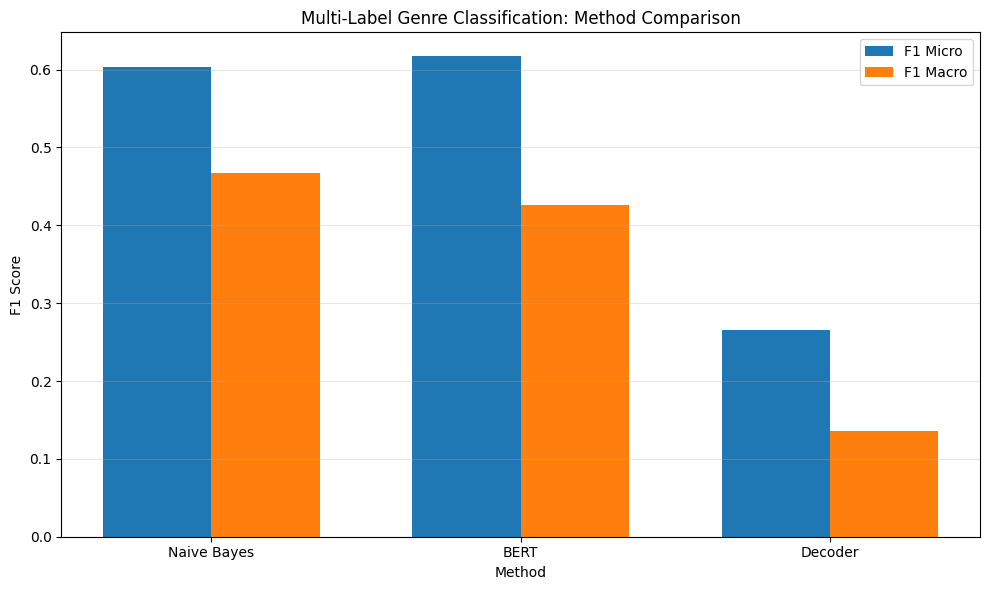


Summary of Results:
Method          F1 Micro     F1 Macro    
----------------------------------------
Naive Bayes     0.6039       0.4669      
BERT            0.6171       0.4259      
Decoder         0.2650       0.1361      


In [28]:
# Compare all three methods
import matplotlib.pyplot as plt

methods = ['Naive Bayes', 'BERT', 'Decoder']
f1_micro_scores = [
    nb_val_metrics['f1_micro'],
    bert_val_results['eval_f1_micro'],
    decoder_metrics['f1_micro']
]
f1_macro_scores = [
    nb_val_metrics['f1_macro'],
    bert_val_results['eval_f1_macro'],
    decoder_metrics['f1_macro']
]

# Create comparison plot
x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, f1_micro_scores, width, label='F1 Micro')
ax.bar(x + width/2, f1_macro_scores, width, label='F1 Macro')

ax.set_xlabel('Method')
ax.set_ylabel('F1 Score')
ax.set_title('Multi-Label Genre Classification: Method Comparison')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSummary of Results:")
print(f"{'Method':<15} {'F1 Micro':<12} {'F1 Macro':<12}")
print("-" * 40)
for method, micro, macro in zip(methods, f1_micro_scores, f1_macro_scores):
    print(f"{method:<15} {micro:<12.4f} {macro:<12.4f}")